In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Isso vai descompactar os vídeos direto na máquina virtual do Google em segundos!
#!unzip -q "/content/drive/MyDrive/tcc/dataset_libras.zip" -d "/content/dataset_libras"
!unzip -q "/content/drive/MyDrive/TCC-Evelyn-2026.1/projeto/dataset_minds.zip" -d "/content/dataset_minds"

print("✅ Dataset descompactado com sucesso na memória rápida!")


Mounted at /content/drive
✅ Dataset descompactado com sucesso na memória rápida!


In [2]:
import os
import cv2
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import TimeDistributed, LSTM, Dense, GlobalAveragePooling2D, Dropout, Input, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

#configurações do modelo de treino
IMG_SIZE = 128                                  #resolucao das imagens
MAX_FRAMES = 30       # quantidade fixa de frames que a LSTM vai processar de acordo com a média de frames
BATCH_SIZE = 16                                  #sequencia de amostras
EPOCHS = 30                                     #numero de vezes que o algoritmo percorre o conjunto
BASE_PATH = '/content/dataset_minds/dataset_minds'

Analisando pastas...

=== RESUMO DOS FRAMES ===
Total de vídeos analisados: 800
Mínimo de frames: 30
Máximo de frames: 30
Média: 30.0
Mediana: 30.0
75% dos vídeos têm até: 30.0 frames
Tempo de contagem de 24000 frames = 0.0018 minutos


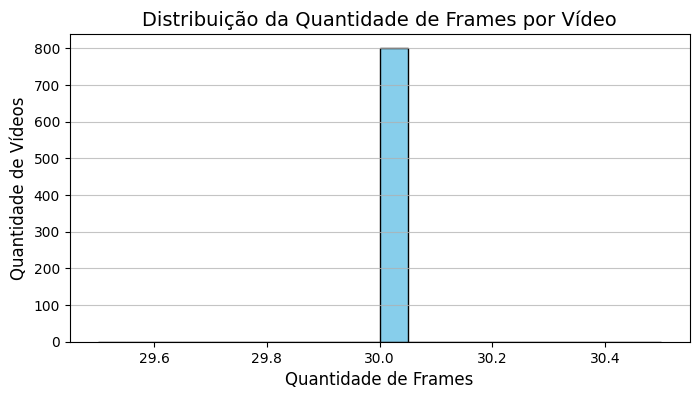

In [3]:
#BASE_PATH = r'..\data\pre_processado\yolo11_resultado_teste_rede_14_05_total'

quant_frames = []
classes = []

print("Analisando pastas...")

inicio = time.time()

#classe para organizar o nome das classes e também contar a médida de frames para aplicar na variavel MAX_FRAMES
for folder_name in os.listdir(BASE_PATH):
    folder_path = os.path.join(BASE_PATH, folder_name)

    if os.path.isdir(folder_path):
        num_frames = 0
        todos_os_itens = os.listdir(folder_path)
        for f in todos_os_itens:
            caminho_completo = os.path.join(folder_path, f)
            if os.path.isfile(caminho_completo):
                num_frames += 1  # Soma 1 para cada arquivo de imagem encontrado
        quant_frames.append(num_frames)
        nome_classe = folder_name.split('_')[0]
        classes.append(nome_classe)


fim = time.time()
tempo = (fim-inicio)/60


# transforma em array numpy para facilitar as estatísticas
quant_frames = np.array(quant_frames)

#dados
print("\n=== RESUMO DOS FRAMES ===")
print(f"Total de vídeos analisados: {len(quant_frames)}")
print(f"Mínimo de frames: {np.min(quant_frames)}")
print(f"Máximo de frames: {np.max(quant_frames)}")
print(f"Média: {np.mean(quant_frames):.1f}")
print(f"Mediana: {np.median(quant_frames):.1f}")
print(f"75% dos vídeos têm até: {np.percentile(quant_frames, 75):.1f} frames")
print(f"Tempo de contagem de {np.sum(quant_frames)} frames = {tempo:.4f} minutos")

#grafico
plt.figure(figsize=(8, 4))
plt.hist(quant_frames, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribuição da Quantidade de Frames por Vídeo', fontsize=14)
plt.xlabel('Quantidade de Frames', fontsize=12)
plt.ylabel('Quantidade de Vídeos', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()



In [ ]:
def carregar_frames_pasta(folder_path, n_frames=MAX_FRAMES, img_size=IMG_SIZE, augment=False):
    frames = []

    imagens = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    imagens.sort(key=lambda x: int(x.replace('frame_', '').replace('.jpg', '')))
    imagens = imagens[:n_frames]

    if len(imagens) == 0:
        return np.zeros((n_frames, img_size, img_size, 3))

    # Sorteia transformacoes UMA VEZ por video (mesma transformacao em todos os frames)
    aplicar_flip = augment and random.random() > 0.5
    fator_brilho = random.uniform(0.8, 1.2) if augment else 1.0
    angulo_rot   = random.uniform(-10, 10)  if augment else 0.0

    for img_file in imagens:
        img_path = os.path.join(folder_path, img_file)
        img = cv2.imread(img_path)

        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = (img / 255.0).astype(np.float32)

            if aplicar_flip:
                img = img[:, ::-1, :]                               # espelha horizontalmente
            if fator_brilho != 1.0:
                img = np.clip(img * fator_brilho, 0, 1)             # ajusta brilho
            if angulo_rot != 0.0:
                h, w = img.shape[:2]
                M = cv2.getRotationMatrix2D((w / 2, h / 2), angulo_rot, 1.0)
                img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)

            frames.append(img)

    return np.array(frames)


In [5]:
#inicialização
print("TensorFlow version:", tf.__version__)
print("GPU disponível:" if tf.config.list_physical_devices('GPU') else "Usando CPU")



TensorFlow version: 2.20.0
GPU disponível:


In [6]:
class GeradorDeVideos(tf.keras.utils.Sequence):
    def __init__(self, caminhos_pastas, rotulos_inteiros, num_classes, batch_size, max_frames, img_size, shuffle=True):
        self.caminhos    = caminhos_pastas
        self.rotulos     = rotulos_inteiros
        self.num_classes = num_classes
        self.batch_size  = batch_size
        self.max_frames  = max_frames
        self.img_size    = img_size
        self.shuffle     = shuffle
        self.indices     = np.arange(len(self.caminhos))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.caminhos) / float(self.batch_size)))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)  # embaralha apenas no treino

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        lote_caminhos = [self.caminhos[i] for i in batch_indices]
        lote_rotulos  = [self.rotulos[i]  for i in batch_indices]

        X_batch = []
        for folder_path in lote_caminhos:
            frames = carregar_frames_pasta(folder_path, self.max_frames, self.img_size, augment=self.shuffle)
            X_batch.append(frames)

        X_batch = np.array(X_batch, dtype=np.float32)
        y_batch = to_categorical(lote_rotulos, num_classes=self.num_classes)
        return X_batch, y_batch

caminhos_totais = []
rotulos_totais  = []

todos_os_itens = os.listdir(BASE_PATH)
folders = [item for item in todos_os_itens if os.path.isdir(os.path.join(BASE_PATH, item))]

print(f'Listando {len(folders)} pastas (Pesa 0 MB na RAM)...')

for folder_name in folders:
    folder_path = os.path.join(BASE_PATH, folder_name)
    class_name  = folder_name.rsplit('_', 1)[0]
    caminhos_totais.append(folder_path)
    rotulos_totais.append(class_name)

print('Total de caminhos salvos prontos para o Gerador:', len(caminhos_totais))


Listando 800 pastas (Pesa 0 MB na RAM)...
Total de caminhos salvos prontas para o Gerador: 800


In [7]:
import pandas as pd

encoder     = LabelEncoder()
y_integers  = encoder.fit_transform(rotulos_totais)
class_names = encoder.classes_
n_classes   = len(class_names)

DRIVE_PATH = '/content/drive/MyDrive/TCC-Evelyn-2026.1/projeto'
CSV_TREINO = f'{DRIVE_PATH}/dados_treino_oficial.csv'
CSV_TESTE  = f'{DRIVE_PATH}/dados_teste_oficial.csv'

if os.path.exists(CSV_TREINO) and os.path.exists(CSV_TESTE):
    print('✅ Carregando split congelado do Drive...')
    df_treino = pd.read_csv(CSV_TREINO)
    df_teste  = pd.read_csv(CSV_TESTE)
    cam_train = df_treino['Caminho'].tolist()
    rot_train = df_treino['Rotulo'].tolist()
    cam_test  = df_teste['Caminho'].tolist()
    rot_test  = df_teste['Rotulo'].tolist()
else:
    print('📂 CSVs nao encontrados. Criando e salvando novo split...')
    cam_train, cam_test, rot_train, rot_test = train_test_split(
        caminhos_totais, y_integers,
        test_size=0.2, random_state=42, stratify=y_integers
    )
    pd.DataFrame({'Caminho': cam_train, 'Rotulo': rot_train}).to_csv(CSV_TREINO, index=False)
    pd.DataFrame({'Caminho': cam_test,  'Rotulo': rot_test }).to_csv(CSV_TESTE,  index=False)
    print('✅ Split salvo! Proximas execucoes vao reusar este split.')

print(f'\nClasses cadastradas: {class_names}')
print(f'Videos no Treino: {len(cam_train)} | Videos no Teste: {len(cam_test)}')
print('\n💡 Para resetar o split (ex: mudou o dataset), apague os CSVs no Drive e execute novamente.')

gerador_treino = GeradorDeVideos(cam_train, rot_train, n_classes, BATCH_SIZE, MAX_FRAMES, IMG_SIZE, shuffle=True)
gerador_teste  = GeradorDeVideos(cam_test,  rot_test,  n_classes, BATCH_SIZE, MAX_FRAMES, IMG_SIZE, shuffle=False)


Classes cadastradas: ['acontecer' 'aluno' 'amarelo' 'america' 'aproveitar' 'bala' 'banco'
 'banheiro' 'barulho' 'cinco' 'conhecer' 'espelho' 'esquina' 'filho'
 'maca' 'medo' 'ruim' 'sapo' 'vacina' 'vontade']
Vídeos no Treino: 640 | Vídeos no Teste: 160


In [ ]:
# Celula desativada: a logica de salvar o split foi movida para a celula anterior.


In [8]:
def avaliacao_modelo(model, cam_teste, rot_teste, history, classes):

    # Gerador de avaliacao sem embaralhamento: garante que y_pred bate com rot_teste
    gerador_eval = GeradorDeVideos(
        cam_teste, rot_teste, len(classes), BATCH_SIZE, MAX_FRAMES, IMG_SIZE, shuffle=False
    )

    # =====================================================================
    # 1. GRAFICOS COMPORTAMENTAIS
    # =====================================================================
    if history.history['accuracy']:
        plt.figure(figsize=(14, 5))

        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Treino (Aprendizado)', color='blue')
        plt.plot(history.history['val_accuracy'], label='Validacao (Generalizacao)', color='orange')
        plt.title('Curvas de Acuracia (Accuracy)\nMonitoramento de Overfitting')
        plt.xlabel('Epocas (Epochs)')
        plt.ylabel('Acuracia')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Treino (Perda)', color='blue')
        plt.plot(history.history['val_loss'], label='Validacao (Perda)', color='orange')
        plt.title('Curvas de Perda (Loss)\nConvergencia e Estabilidade')
        plt.xlabel('Epocas (Epochs)')
        plt.ylabel('Perda')
        plt.legend()

        plt.savefig('graficos_comportamentais.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print('ℹ️ Sem historico de treino — graficos de curva ignorados.')

    # =====================================================================
    # 2. PREVISOES DA REDE NEURAL
    # =====================================================================
    probabilidades = model.predict(gerador_eval, verbose=0)
    y_pred = np.argmax(probabilidades, axis=1)
    y_true = np.array(rot_teste)  # ordem garantida pelo gerador sem shuffle

    # =====================================================================
    # 3. MATRIZ DE CONFUSAO
    # =====================================================================
    indices_classes = range(len(classes))
    matriz_confusao = confusion_matrix(y_true, y_pred, labels=indices_classes)

    plt.figure(figsize=(10, 8))
    sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('O que a IA PREVIU (Rotulos Previstos)', fontsize=12)
    plt.ylabel('O que era REAL (Rotulos Reais)', fontsize=12)
    plt.title('Matriz de Confusao (TP, TN, FP, FN)', fontsize=14)
    plt.savefig('matriz_de_confusao.png', dpi=300, bbox_inches='tight')
    plt.show()

    # =====================================================================
    # 4. METRICAS GLOBAIS
    # =====================================================================
    acuracia_global = accuracy_score(y_true, y_pred)
    precision_global, recall_global, f1_global, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )

    print('\n' + '='*50)
    print('🏆 METRICAS GLOBAIS DO MODELO (RESUMO)')
    print('='*50)
    print(f' -> Acuracia (Accuracy): {acuracia_global:.4f}')
    print(f' -> F1-Score (Media):    {f1_global:.4f}')
    print(f' -> Precisao (Precision):{precision_global:.4f}')
    print(f' -> Revocacao (Recall):  {recall_global:.4f}')
    print('='*50)

    # =====================================================================
    # 5. RESULTADO POR CLASSE E EXPORTACAO CSV
    # =====================================================================
    print('\n📊 RESULTADOS DETALHADOS POR CLASSE')
    print('-' * 50)

    precision_arr, recall_arr, f1_arr, support_arr = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(len(classes))), average=None, zero_division=0
    )

    linhas_csv = []

    for i, nome_classe in enumerate(classes):
        total_real            = matriz_confusao[i].sum()
        verdadeiros_positivos = matriz_confusao[i][i]
        acuracia_classe       = (verdadeiros_positivos / total_real) if total_real > 0 else 0

        print(f'\nSinal Real: {nome_classe.upper()}')
        print(f'  Acuracia Isolada: {acuracia_classe:.2f}')
        print(f'  Precision: {precision_arr[i]:.2f}')
        print(f'  Recall:    {recall_arr[i]:.2f}')
        print(f'  F1-Score:  {f1_arr[i]:.2f}')

        saidas_previstas = []
        for j, nome_classe_prevista in enumerate(classes):
            quantidade_prevista = matriz_confusao[i][j]
            if quantidade_prevista > 0:
                status = '✅ Acertou' if i == j else '❌ Confundiu com'
                print(f'  -> {status}: {nome_classe_prevista} ({quantidade_prevista} vezes)')
                saidas_previstas.append(nome_classe_prevista)

        linhas_csv.append({
            'Classe Esperada':            nome_classe,
            'Respostas da IA':            ', '.join(saidas_previstas),
            'Acuracia':                   round(acuracia_classe, 4),
            'Precisao':                   round(precision_arr[i], 4),
            'Revocacao (Recall)':         round(recall_arr[i], 4),
            'F1-Score':                   round(f1_arr[i], 4),
            'Total de Videos (Support)':  int(support_arr[i])
        })

    df_metricas = pd.DataFrame(linhas_csv)
    csv_path    = 'metricas_completas_por_classe.csv'
    df_metricas.to_csv(csv_path, index=False, encoding='utf-8-sig')
    print(f'\n✅ Planilha de metricas salva com sucesso em: {csv_path}')


In [9]:
#definições da rede neural

n_classes = len(class_names)

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(IMG_SIZE, IMG_SIZE, 3))                                        #largura, largura, canais de cor

base_model.trainable = False                                                                         # congela os pesos da ResNet para não ter alterações ao longo do processo

#cada camada alimenta a próxima em linha reta
model = Sequential([
    TimeDistributed(base_model, input_shape=(MAX_FRAMES, IMG_SIZE, IMG_SIZE, 3)),       #aplicaão da resnet em cada imagem, funciona como um loop

    # B. A Camada Totalmente Conectada intermediária citada na Seção 4.4
    TimeDistributed(Dense(512, activation='relu')),
    BatchNormalization(),

    # C. Extrator Temporal (LSTM)
    LSTM(256, return_sequences=False),
    Dropout(0.5),

    Dense(n_classes, activation='softmax')

    # TimeDistributed(GlobalAveragePooling2D()),                                          #diminui o tamanho dos dados gerados de matriz bidimensionais para matriz

    # # LSTM(128, return_sequences=True),          # analise da sequencia de frames, entregando uma resposta apenas no final
    # # Dropout(0.3),                              #camada de segurança contra o overfitting (quando o modelo decora o treino mas erra no teste)
    # # LSTM(64, return_sequences=False),              #camada intermediária totalmente conectada com 64 neurônios     ********** PESQUISAR***********
    # # Dropout(0.3),

    # # Dense(64, activation='relu'),
    # # Dense(n_classes, activation='softmax')     #o mesmo n de neurônios que a quantidade de classes que você possui e softmax transforma a saída final em probabilidades que somam 100%

    # LSTM(64, return_sequences=False),
    # BatchNormalization(),
    # Dropout(0.5), # Aumentado para evitar decoreba

    # Dense(64, activation='relu'),
    # Dropout(0.3),
    # Dense(n_classes, activation='softmax')

])

model.compile(
    optimizer=Adam(learning_rate=0.0005, weight_decay=0.0005),      #algoritmo que ajustará os pesos da LSTM e das camadas densas
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy'])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 30, 2048)       │    23,587,712 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 30, 512)        │     1,049,088 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,431,444 (97.01 MB)

 Trainable params: 1,842,708 (7.03 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

🚀 Iniciando o treinamento com os parâmetros do artigo...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 848ms/step - accuracy: 0.0713 - loss: 3.0493
Epoch 1: saving model to /content/drive/MyDrive/TCC-Evelyn-2026.1/projeto/backup_modelo.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TCC-Evelyn-2026.1/projeto/backup_modelo.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 302s 3s/step - accuracy: 0.0781 - loss: 3.0133 - val_accuracy: 0.0500 - val_loss: 3.1444 - learning_rate: 5.0000e-04
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 905ms/step - accuracy: 0.1906 - loss: 2.7206
Epoch 2: saving model to /content/drive/MyDrive/TCC-Evelyn-2026.1/projeto/backup_modelo.keras

Epoch 2: finished saving model to /content/drive/MyDrive/TCC-Evelyn-2026.1/projeto/backup_modelo.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.1813 - loss: 2.7173 - val_accuracy: 0.0500 - val_loss: 3.5396 - learning_rate: 5.0000e-04
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 916ms/step - accuracy: 0.2539 - loss: 2.5183
Epoch 3: saving model to /content/drive/MyDrive/TCC-Evelyn-

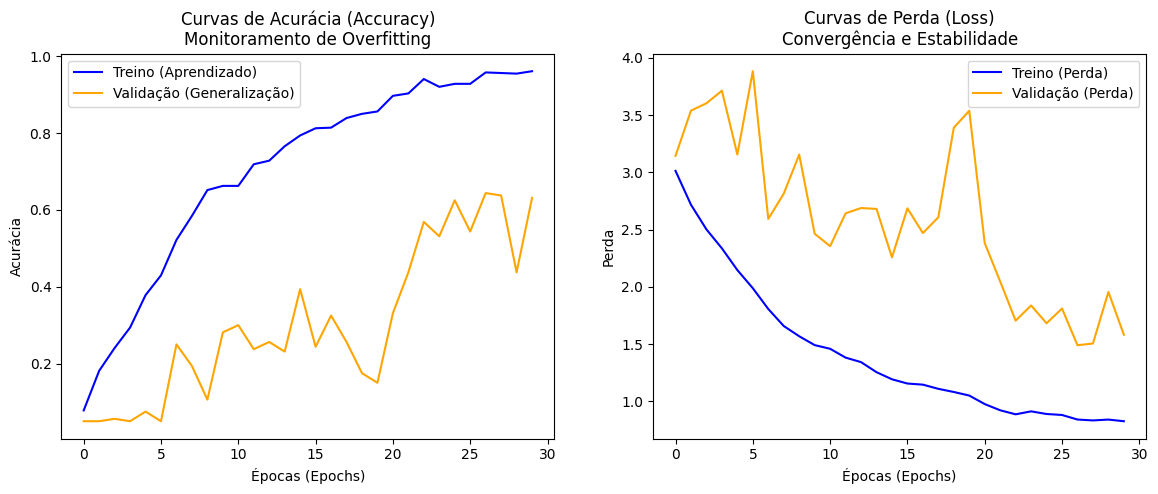

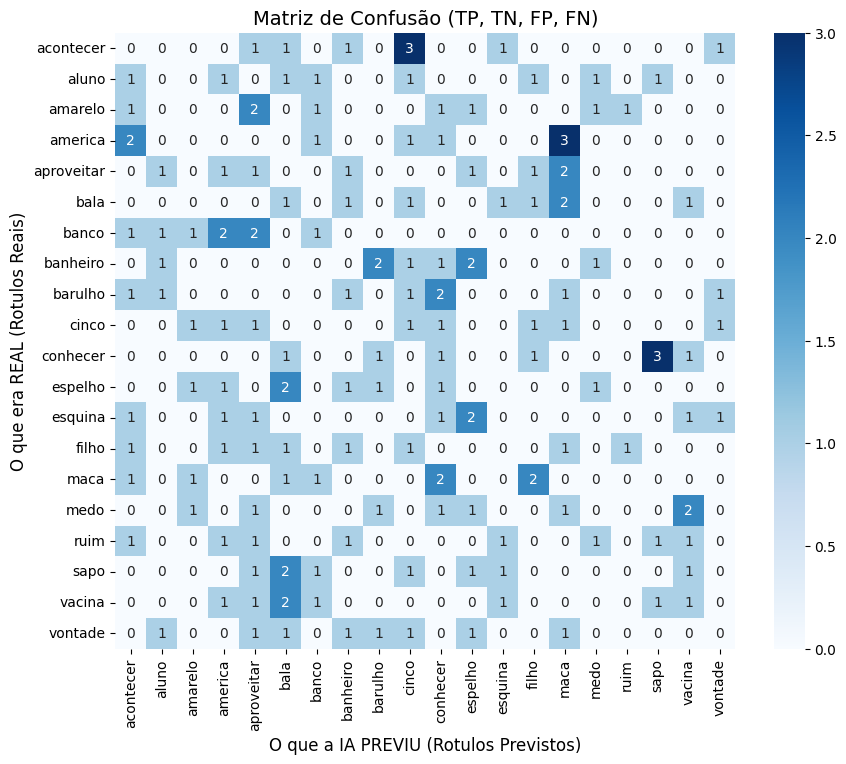


🏆 MÉTRICAS GLOBAIS DO MODELO (RESUMO)
 -> Acurácia (Accuracy): 0.0375 (Proporção total de acertos)
 -> F1-Score (Média):  0.0322 (Equilíbrio entre Precisão e Revocação)
 -> Precisão (Precision):0.0291 (Dos que a IA disse ser X, quantos realmente eram X?)
 -> Revocação (Recall):  0.0375 (De todos os X reais, quantos a IA conseguiu achar?)

📊 RESULTADOS DETALHADOS POR CLASSE
--------------------------------------------------

Sinal Real: ACONTECER
  Acurácia Isolada: 0.00
  Precision: 0.00
  Recall:    0.00
  F1-Score:  0.00
  -> ❌ Confundiu com: aproveitar (1 vezes)
  -> ❌ Confundiu com: bala (1 vezes)
  -> ❌ Confundiu com: banheiro (1 vezes)
  -> ❌ Confundiu com: cinco (3 vezes)
  -> ❌ Confundiu com: esquina (1 vezes)
  -> ❌ Confundiu com: vontade (1 vezes)

Sinal Real: ALUNO
  Acurácia Isolada: 0.00
  Precision: 0.00
  Recall:    0.00
  F1-Score:  0.00
  -> ❌ Confundiu com: acontecer (1 vezes)
  -> ❌ Confundiu com: america (1 vezes)
  -> ❌ Confundiu com: bala (1 vezes)
  -> ❌ Confund

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 1. O Early Stopping (Rede de segurança mais tolerante)
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,          # <-- AUMENTADO PARA 15 (Para dar chance ao freio agir)
    min_delta=0.005,
    restore_best_weights=True,
    start_from_epoch=10
)

# 2. O Freio Dinâmico (Exatamente como no Artigo)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # Vigia o erro de validação
    factor=0.5,           # Multiplica a taxa de aprendizado por 0.5 (corta pela metade)
    patience=5,           # <-- ALINHADO COM O ARTIGO: Espera 5 épocas antes de agir
    min_lr=1e-6,          # Limite mínimo de velocidade para não parar a rede totalmente
    verbose=1             # Imprime um aviso amarelo no console quando o freio for acionado
)

# 3. O Checkpoint (Seu "Save Game" automático no Drive novo)
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/TCC-Evelyn-2026.1/projeto/backup_modelo.keras',
    save_best_only=False, # Salva todas as épocas (não apenas a melhor) para não perder progresso
    save_freq='epoch',    # Salva ao final de cada época
    verbose=1             # Imprime no console: "Epoch X: saving model to..."
)

# 4. Treinamento com os TRÊS callbacks ativados
print("🚀 Iniciando o treinamento com os parâmetros do artigo...")
history = model.fit(
    gerador_treino,
    validation_data=gerador_teste,
    epochs=EPOCHS, # Lembre-se de que no Bloco 6 o EPOCHS deve estar igual a 50
    callbacks=[early_stop, reduce_lr, checkpoint]
)


#model.save('modelo_lstm_final.h5')
#model.save('/content/drive/MyDrive/tcc/modelo_lstm_final.keras')
model.save('/content/drive/MyDrive/TCC-Evelyn-2026.1/projeto/modelo_lstm_final.keras')

# A CHAMADA AGORA USA O GERADOR E OS ROTULOS DO TESTE:
avaliacao_modelo(model, cam_test, rot_test, history, class_names)